In [59]:
# Customer Churn Prediction - IBM Telco Dataset
# Group Members: Daniel Eckman, Cole Compton, Melanie Vogt

# Goal:
# Build a model that predicts whether a customer will churn,
# then identify the features that contribute most to churn.

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mysql.connector
from mysql.connector import Error

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [61]:
# Configure MySQL
try:
    connection = mysql.connector.connect(
        host='localhost',
        user='root',
        password='root123',
        database='telco_churn_db'
    )
    
    if connection.is_connected():
        print("Successfully connected to MySQL database")
        
        # Load data using SQL query
        query = f"SELECT * FROM {'customer_churn'}"
        df = pd.read_sql(query, connection)
        
        connection.close()
        print(f"Data loaded successfully: {df.shape}")
        
except Error as e:
    print(f"Error connecting to MySQL: {e}")

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Successfully connected to MySQL database
Data loaded successfully: (7043, 33)

Shape: (7043, 33)

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason']


,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,0002-ORFBO,1,United States,California,Frazier Park,93225,"34.827662, -118.999073",34.827662,-118.999073,Female,...,One year,Yes,Mailed check,65.6,593.3,No,0,65,2205,NaN
1,0003-MKNFE,1,United States,California,Glendale,91206,"34.162515, -118.203869",34.162515,-118.203869,Male,...,Month-to-month,No,Mailed check,59.9,542.4,No,0,66,5414,NaN
2,0004-TLHLJ,1,United States,California,Costa Mesa,92627,"33.645672, -117.922613",33.645672,-117.922613,Male,...,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,1,71,4479,Price too high
3,0011-IGKFF,1,United States,California,Martinez,94553,"38.014457, -122.115432",38.014457,-122.115432,Male,...,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,1,99,3714,Product dissatisfaction
4,0013-EXCHZ,1,United States,California,Camarillo,93010,"34.227846, -119.079903",34.227846,-119.079903,Female,...,Month-to-month,Yes,Mailed check,83.9,267.4,Yes,1,68,3464,Network reliability


In [62]:
# Drop columns that are IDs, too detailed, or leak churn information
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip_Code",
    "Lat_Long",
    "Latitude",
    "Longitude",
    "Churn_Label",
    "Churn_Score",
    "CLTV",
    "Churn_Reason"
]

df = df.drop(columns=drop_cols, errors="ignore")

# Convert Total Charges to numeric
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")
df["Total_Charges"] = df["Total_Charges"].fillna(df["Total_Charges"].median())

# Use Churn Value as the target
df = df.rename(columns={"Churn_Value": "Churn"})

print("Data Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean():.2%}")

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior_Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure_Months      7043 non-null   int64  
 5   Phone_Service      7043 non-null   str    
 6   Multiple_Lines     7043 non-null   str    
 7   Internet_Service   7043 non-null   str    
 8   Online_Security    7043 non-null   str    
 9   Online_Backup      7043 non-null   str    
 10  Device_Protection  7043 non-null   str    
 11  Tech_Support       7043 non-null   str    
 12  Streaming_TV       7043 non-null   str    
 13  Streaming_Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless_Billing  7043 non-null   str    
 16  Payment_Method     7043 

In [63]:
# Create new 6 features that might be predictive

# 1. Average monthly charge (Total Charges / Tenure)
df['Avg_Monthly_Charge'] = df['Total_Charges'] / (df['Tenure_Months'] + 1)  # +1 avoids division by zero

# 2. Tenure groups (categorize customers by tenure length)
df['Tenure_Group'] = pd.cut(df['Tenure_Months'], 
                             bins=[0, 12, 24, 48, 72], 
                             labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'])

# 3. Total services (count of additional services)
service_cols = ['Online_Security', 'Online_Backup', 'Device_Protection', 
                'Tech_Support', 'Streaming_TV', 'Streaming_Movies']

# Count 'Yes' responses
df['Total_Services'] = 0
for col in service_cols:
    if col in df.columns:
        df['Total_Services'] += (df[col] == 'Yes').astype(int)

# 4. Has any service (binary)
df['Has_Services'] = (df['Total_Services'] > 0).astype(int)

# 5. Senior with dependents
df['Senior_With_Dependents'] = ((df['Senior_Citizen'] == 'Yes') & 
                                 (df['Dependents'] == 'Yes')).astype(int)

# 6. Paperless and auto-payment
df['Paperless_Auto_Pay'] = ((df['Paperless_Billing'] == 'Yes') & 
                             (df['Payment_Method'].str.contains('automatic', case=False, na=False))).astype(int)

print("New Features Created:")
print(df[['Avg_Monthly_Charge', 'Tenure_Group', 'Total_Services', 'Has_Services', 
          'Senior_With_Dependents', 'Paperless_Auto_Pay']].head())

New Features Created:
   Avg_Monthly_Charge Tenure_Group  Total_Services  Has_Services  \
0           59.330000        0-1yr               3             1   
1           54.240000        0-1yr               1             1   
2           56.170000        0-1yr               1             1   
3           88.417857        1-2yr               4             1   
4           66.850000        0-1yr               2             1   

   Senior_With_Dependents  Paperless_Auto_Pay  
0                       0                   0  
1                       0                   0  
2                       0                   0  
3                       0                   0  
4                       0                   0  


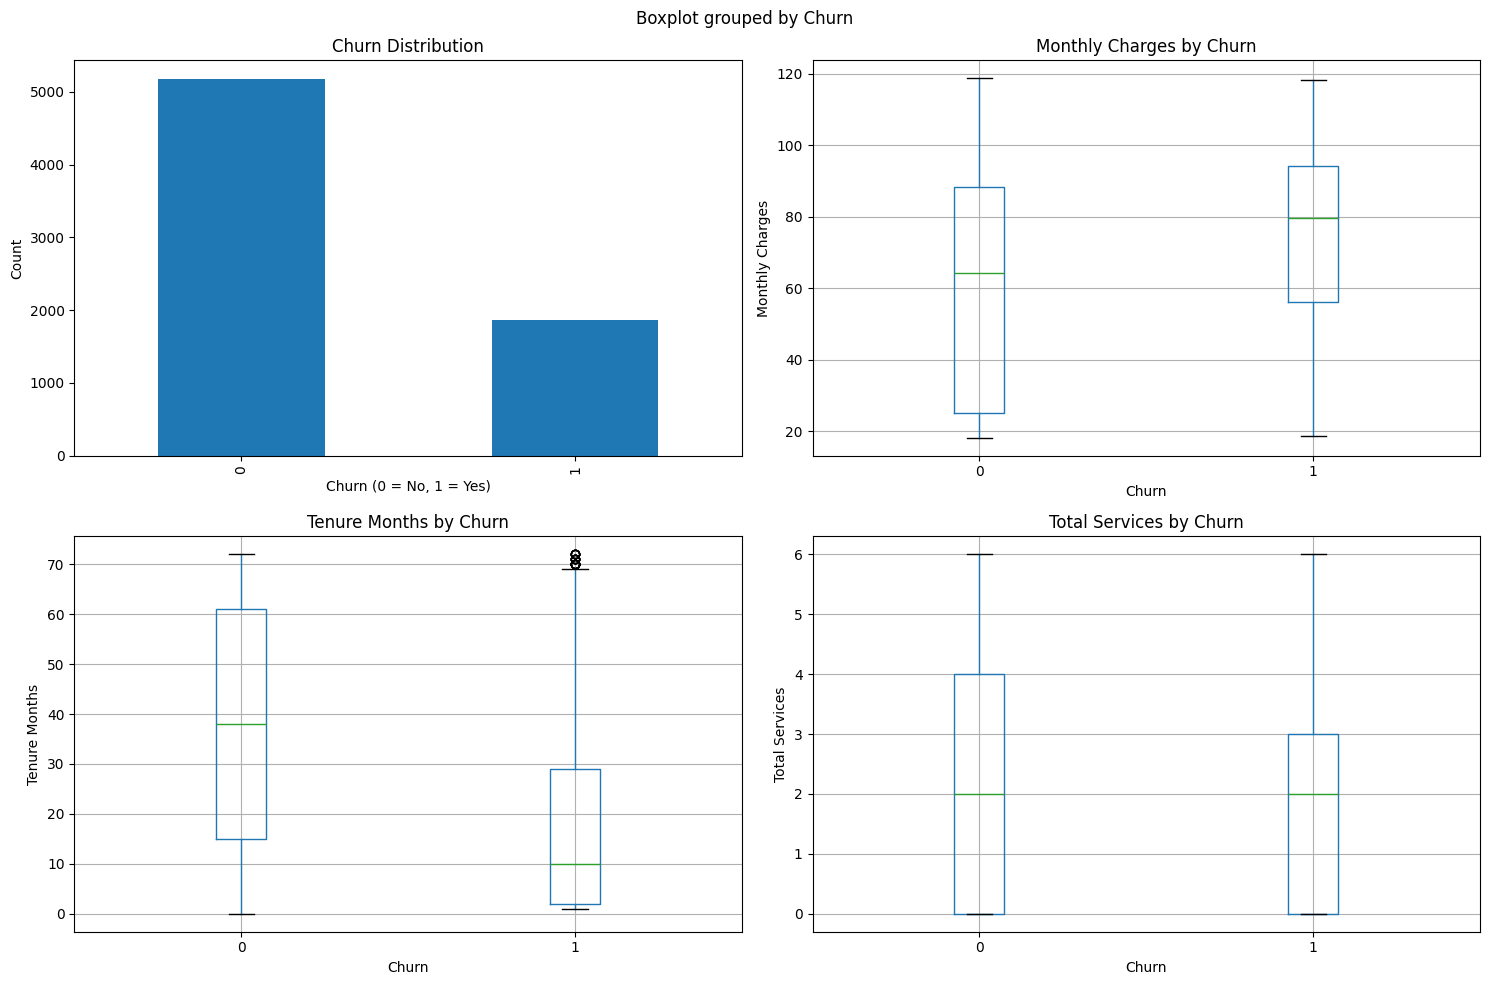

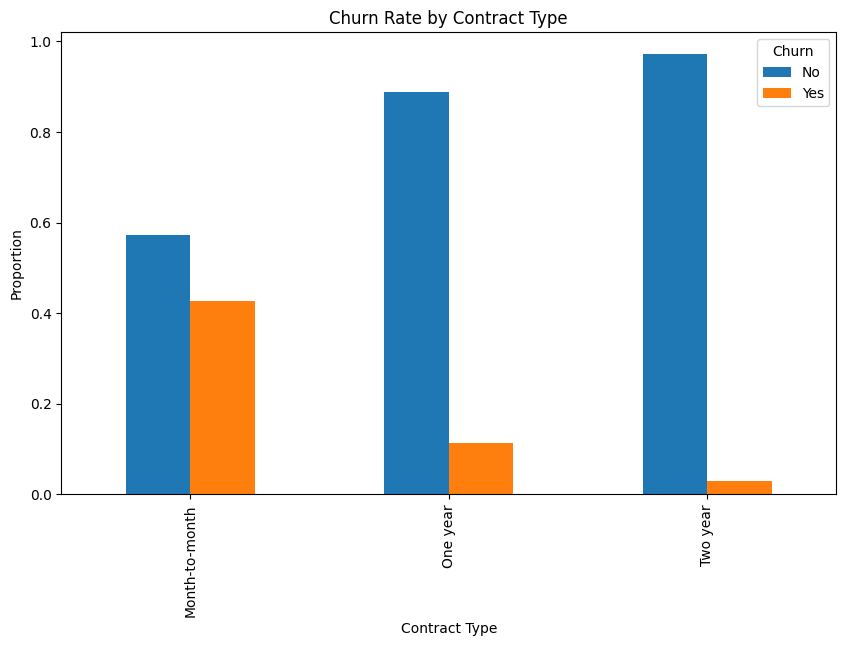

In [64]:
# Visualize churn distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Churn distribution
df["Churn"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Churn Distribution")
axes[0, 0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0, 0].set_ylabel("Count")

# Monthly charges by churn
df.boxplot(column="Monthly_Charges", by="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Monthly Charges by Churn")
axes[0, 1].set_xlabel("Churn")
axes[0, 1].set_ylabel("Monthly Charges")

# Tenure by churn
df.boxplot(column="Tenure_Months", by="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Tenure Months by Churn")
axes[1, 0].set_xlabel("Churn")
axes[1, 0].set_ylabel("Tenure Months")

# Total services by churn
df.boxplot(column="Total_Services", by="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Total Services by Churn")
axes[1, 1].set_xlabel("Churn")
axes[1, 1].set_ylabel("Total Services")

plt.tight_layout()
plt.show()

# Contract type impact
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar", figsize=(10, 6))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xlabel("Contract Type")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()

In [65]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded shape:", df_encoded.shape)
print("\nEncoded columns:", df_encoded.columns.tolist())

# Separate features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Training set churn rate: {y_train.mean():.2%}")

Encoded shape: (7043, 39)

Encoded columns: ['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'Churn', 'Avg_Monthly_Charge', 'Total_Services', 'Has_Services', 'Senior_With_Dependents', 'Paperless_Auto_Pay', 'Gender_Male', 'Senior_Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone_Service_Yes', 'Multiple_Lines_No phone service', 'Multiple_Lines_Yes', 'Internet_Service_Fiber optic', 'Internet_Service_No', 'Online_Security_No internet service', 'Online_Security_Yes', 'Online_Backup_No internet service', 'Online_Backup_Yes', 'Device_Protection_No internet service', 'Device_Protection_Yes', 'Tech_Support_No internet service', 'Tech_Support_Yes', 'Streaming_TV_No internet service', 'Streaming_TV_Yes', 'Streaming_Movies_No internet service', 'Streaming_Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless_Billing_Yes', 'Payment_Method_Credit card (automatic)', 'Payment_Method_Electronic check', 'Payment_Method_Mailed check', 'Tenure_Group_1-2yr', 'Tenure_Group_2-4yr', 'Tenu

In [66]:
# Apply SMOTE to balance the classes
# Before, we had many more instances of non-churners than churners, so we create synthetic churners to balance the dataset
print("Before SMOTE:")
print(f"Training set shape: {X_train.shape}")
print(f"Class distribution:\n{y_train.value_counts()}")

smote = SMOTE(random_state=42, sampling_strategy=0.8)  # Create 80% minority to majority ratio
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Training set shape: {X_train_smote.shape}")
print(f"Class distribution:\n{y_train_smote.value_counts()}")
print(f"Training set churn rate: {y_train_smote.mean():.2%}")

Before SMOTE:
Training set shape: (5634, 38)
Class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Training set shape: (7450, 38)
Class distribution:
Churn
0    4139
1    3311
Name: count, dtype: int64
Training set churn rate: 44.44%


# Model 1: Logistic Regression

Performing hyperparameter tuning for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 score: 0.783625890920365

LOGISTIC REGRESSION RESULTS
Accuracy:  0.7651
Precision: 0.5396
Recall:    0.7834
F1 Score:  0.6390

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409


Cross-validation F1 scores: [0.67086331 0.64058235 0.84335561 0.88085106 0.88247713]
Mean CV F1 score: 0.7836 (+/- 0.2116)


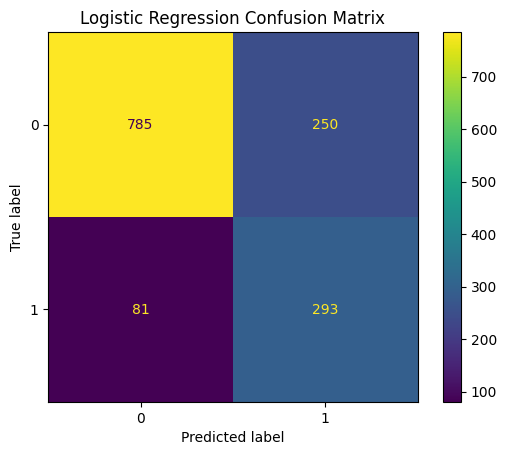

In [67]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning with GridSearchCV
print("Performing hyperparameter tuning for Logistic Regression...")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

log_model = LogisticRegression(max_iter=5000, random_state=42)

grid_search_lr = GridSearchCV(
    log_model,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train_smote)

print("\nBest parameters:", grid_search_lr.best_params_)
print("Best CV F1 score:", grid_search_lr.best_score_)

# Use best model
log_model_best = grid_search_lr.best_estimator_

# Evaluate on test set with custom threshold (significantly improves recall at the cost of a small amount of precision)
threshold = 0.35
y_pred_log_proba = log_model_best.predict_proba(X_test_scaled)[:, 1]
y_pred_log = (y_pred_log_proba >= threshold).astype(int)

print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_log):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Cross-validation scores
cv_scores_lr = cross_val_score(log_model_best, X_train_scaled, y_train_smote, 
                                cv=5, scoring='f1')
print(f"\nCross-validation F1 scores: {cv_scores_lr}")
print(f"Mean CV F1 score: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Top 20 Features by Absolute Coefficient:
                                   Feature  Coefficient       Abs
4                           Total_Services    -2.883772  2.883772
3                       Avg_Monthly_Charge    -1.420818  1.420818
0                            Tenure_Months    -1.311563  1.311563
26                        Streaming_TV_Yes     1.111879  1.111879
28                    Streaming_Movies_Yes     1.070361  1.070361
22                   Device_Protection_Yes     0.916305  0.916305
20                       Online_Backup_Yes     0.858221  0.858221
15            Internet_Service_Fiber optic     0.769959  0.769959
18                     Online_Security_Yes     0.732041  0.732041
13         Multiple_Lines_No phone service     0.674146  0.674146
24                        Tech_Support_Yes     0.668244  0.668244
12                       Phone_Service_Yes     0.641705  0.641705
11                          Dependents_Yes    -0.500154  0.500154
33         Payment_Method_Electroni

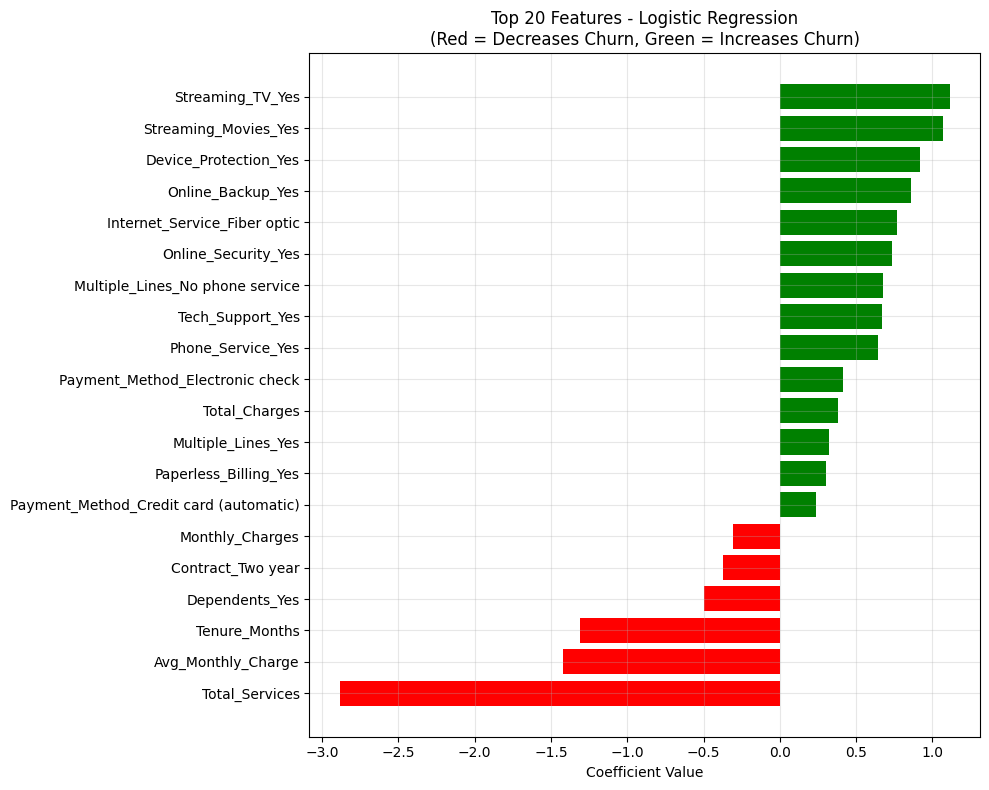

In [68]:
# Feature Importance (top 20)
log_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model_best.coef_[0]
})

log_importance["Abs"] = log_importance["Coefficient"].abs()
log_importance = log_importance.sort_values(by="Abs", ascending=False)

print("Top 20 Features by Absolute Coefficient:")
print(log_importance.head(20))

# Visualize top features
top_features = log_importance.head(20).sort_values(by="Coefficient")

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Features - Logistic Regression\n(Red = Decreases Churn, Green = Increases Churn)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Model 2: Random Forest

In [69]:
# Hyperparameter tuning
print("Performing hyperparameter tuning for Random Forest...")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(
    class_weight='balanced_subsample', # Automatically adjusts weights based on class frequencies
    random_state=42, 
    n_jobs=-1
)

# Use RandomizedSearchCV for faster search (Random Forest has a lot of hyperparameters)
from sklearn.model_selection import RandomizedSearchCV

random_search_rf = RandomizedSearchCV(
    rf_model,
    param_grid_rf,
    n_iter=30,  # Number of random combinations to try
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train_smote, y_train_smote)

print("\nBest parameters:", random_search_rf.best_params_)
print("Best CV F1 score:", random_search_rf.best_score_)

# Use best model
rf_model_best = random_search_rf.best_estimator_

# Evaluate on test set with custom threshold (significantly improves recall at the cost of a small amount of precision)
threshold = 0.35
y_pred_rf_proba = rf_model_best.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_rf_proba >= threshold).astype(int)

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Cross-validation scores
cv_scores_rf = cross_val_score(rf_model_best, X_train_smote, y_train_smote, 
                                cv=5, scoring='f1')
print(f"\nCross-validation F1 scores: {cv_scores_rf}")
print(f"Mean CV F1 score: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

Performing hyperparameter tuning for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best CV F1 score: 0.8148452899651464

RANDOM FOREST RESULTS
Accuracy:  0.7509
Precision: 0.5197
Recall:    0.8102
F1 Score:  0.6332

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Cross-validation F1 scores: [0.73289902 0.71272115 0.85127479 0.88549618 0.89183531]
Mean CV F1 score: 0.8148 (+/- 0.1533)


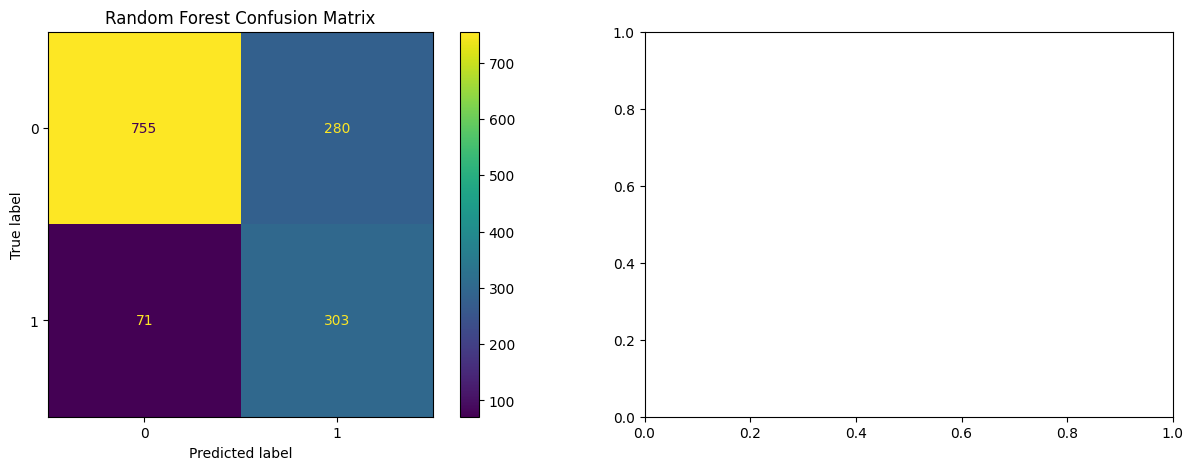

In [70]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")

plt.show()

Top 20 Features by Importance:
                                   Feature  Importance
0                            Tenure_Months    0.115914
2                            Total_Charges    0.113005
33         Payment_Method_Electronic check    0.096991
3                       Avg_Monthly_Charge    0.083504
1                          Monthly_Charges    0.077660
15            Internet_Service_Fiber optic    0.052236
31                   Paperless_Billing_Yes    0.043478
30                       Contract_Two year    0.042051
11                          Dependents_Yes    0.034449
4                           Total_Services    0.033000
37                       Tenure_Group_4+yr    0.028336
9                       Senior_Citizen_Yes    0.019547
29                       Contract_One year    0.019511
7                       Paperless_Auto_Pay    0.019131
14                      Multiple_Lines_Yes    0.017139
8                              Gender_Male    0.016031
10                             Par

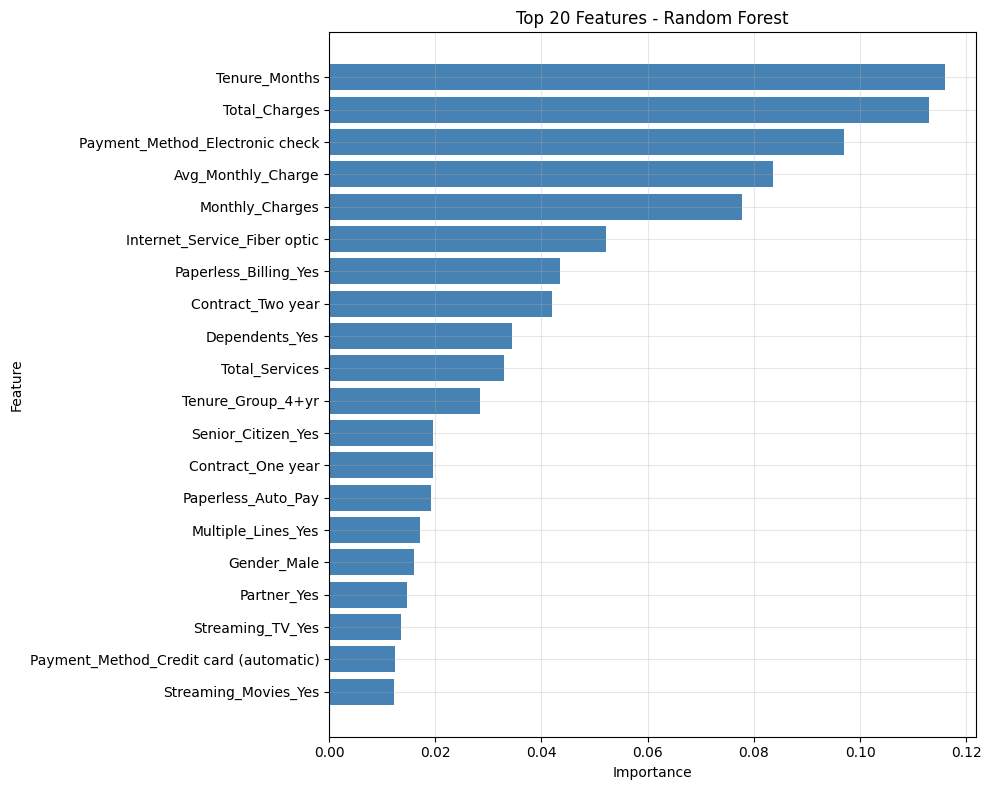

In [71]:
# Feature Importance (top 20)
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model_best.feature_importances_
})
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print("Top 20 Features by Importance:")
print(rf_importance.head(20))

# Visualize
top_rf = rf_importance.head(20).sort_values(by="Importance")

plt.figure(figsize=(10, 8))
plt.barh(top_rf["Feature"], top_rf["Importance"], color='steelblue')
plt.title("Top 20 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Model Comparison


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.765082   0.539595 0.783422  0.639040
      Random Forest  0.750887   0.519726 0.810160  0.633229


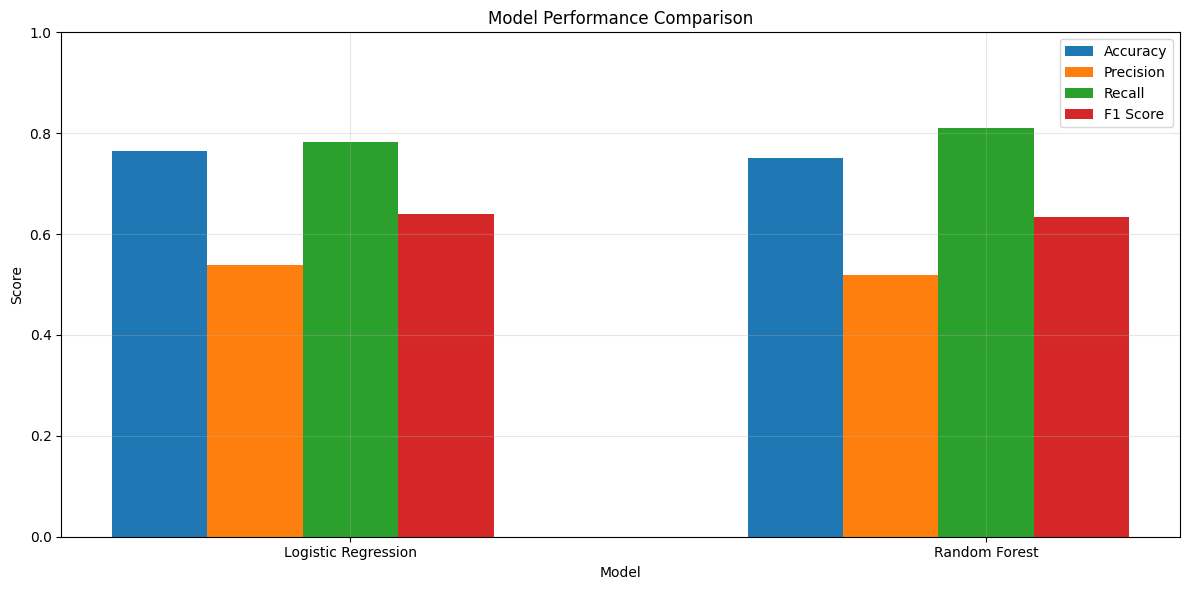

In [72]:
# Compare both models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results.to_string(index=False))

# Visualize comparison
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results['Model']))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for i, metric in enumerate(metrics):
    values = results[metric].values
    ax.bar(x + i * width, values, width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [73]:
# Interpretation:
# Logistic Regression:
# Positive coefficients increase likelihood of churn.
# Negative coefficients decrease likelihood of churn.
#
# Random Forest:
# Higher importance means the feature had more influence on predictions.